# SHAP Analysis — XGBoost Feature Importance

Explain which handcrafted features drive behaviour classification predictions
using SHAP (SHapley Additive exPlanations) on the best XGBoost LOVO model.

In [1]:
import os

os.chdir("../")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from src._config import LABEL_ORDER
from src.classification.datamodule import LabelEncoder

plt.style.use(".matplotlib/ieee.mplstyle")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", ["k", "r", "b", "g"])

CLASS_NAMES = ["None", "Worm", "Locomotor"]
DATASET_DIR = "data/dataset"
EVAL_DIR = "data/eval/20260315_115020_xgboost"

## Load data

In [11]:
features_df = pd.read_parquet(f"{DATASET_DIR}/features_windowed.parquet")
labels_df = pd.read_parquet(f"{DATASET_DIR}/labels.parquet")

skip_cols = {"video_id", "bird_id", "window", "n_frames"}
feat_cols = [c for c in features_df.columns if c not in skip_cols]

label_order = [l for l in LABEL_ORDER if l != "social"]
mask = ~labels_df["behav_label"].isin(["social"])
features_df = features_df[mask.values].reset_index(drop=True)
labels_df = labels_df[mask].reset_index(drop=True)

X = features_df[feat_cols].fillna(features_df[feat_cols].median()).values
le = LabelEncoder(label_order)
y = np.array(le.encode(labels_df["behav_label"].tolist()))
video_ids = features_df["video_id"].values
all_videos = sorted(set(video_ids))

print(f"Samples: {len(X)}, Features: {len(feat_cols)}, Classes: {label_order}")

Samples: 7438, Features: 171, Classes: ['none', 'worm', 'locomotor']


## Compute SHAP values across all LOVO folds

In [12]:
all_shap_values = []
all_X_test = []
all_y_test = []

for fold_idx, test_video in enumerate(all_videos):
    test_mask = video_ids == test_video
    X_test, y_test = X[test_mask], y[test_mask]

    clf = XGBClassifier()
    clf.load_model(f"{EVAL_DIR}/fold_{fold_idx}_{test_video}.json")

    explainer = shap.TreeExplainer(clf)
    shap_vals = explainer.shap_values(X_test)
    all_shap_values.append(shap_vals)
    all_X_test.append(X_test)
    all_y_test.append(y_test)

X_combined = np.concatenate(all_X_test, axis=0)
y_combined = np.concatenate(all_y_test, axis=0)

# Combine SHAP — handle list-of-arrays (multi-class) or 3D array
sample = all_shap_values[0]
if isinstance(sample, list):
    shap_combined = [
        np.concatenate([fold[c] for fold in all_shap_values], axis=0)
        for c in range(len(sample))
    ]
elif isinstance(sample, np.ndarray) and sample.ndim == 3:
    shap_combined = np.concatenate(all_shap_values, axis=0)
else:
    shap_combined = np.concatenate(all_shap_values, axis=0)

def get_class_shap(c):
    """Get SHAP values for class c, handling both formats."""
    if isinstance(shap_combined, list):
        return shap_combined[c]
    elif isinstance(shap_combined, np.ndarray) and shap_combined.ndim == 3:
        return shap_combined[:, :, c]
    return shap_combined

print(f"Combined: {X_combined.shape[0]} samples")

Combined: 7438 samples


## Grouped feature importance (paper figure)

Pool SHAP values across all window statistics (mean, std, q10, q90, …) for each
base feature. Stacked bars show per-class contribution.

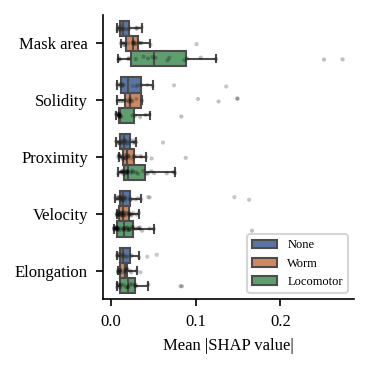

In [45]:
# --- Group feature columns by base name ---
STAT_SUFFIXES = [
    "_median", "_mean", "_skew", "_kurt",
    "_mad", "_std", "_min", "_max",
    "_q10", "_q90", "_iqr", "_cv",
]

def get_base(col):
    for s in STAT_SUFFIXES:
        if col.endswith(s):
            return col[: -len(s)]
    return col

MERGE_MAP = {
    "velocity_autocorr": "velocity",
    "acceleration": "velocity",
    "turning_angle": "velocity",
    "solidity_change": "solidity",
    "elongation_change": "elongation",
    "orientation_velocity": "orientation",
    "area_change_rate": "mask_area",
    "min_dist_to_other": "proximity",
    "mean_dist_to_other": "proximity",
    "dist_change_rate": "proximity",
}

base_to_idx = {}
for i, col in enumerate(feat_cols):
    base = get_base(col)
    base = MERGE_MAP.get(base, base)
    base_to_idx.setdefault(base, []).append(i)

# One row per (feature group, class, statistic) — seaborn computes mean + sd
rows = []
for base, indices in base_to_idx.items():
    for c in range(len(CLASS_NAMES)):
        per_stat = np.abs(get_class_shap(c))[:, indices].mean(axis=0)
        for val in per_stat:
            rows.append({"feature": base, "class": CLASS_NAMES[c], "importance": float(val)})

plot_df = pd.DataFrame(rows)

# Sort by total importance
order = (
    plot_df.groupby("feature")["importance"].mean()
    .sort_values(ascending=False).index.tolist()
)

LABEL_MAP = {
    "mask_area": "Mask area", "aspect_ratio": "Aspect ratio",
    "velocity": "Velocity", "solidity": "Solidity",
    "elongation": "Elongation", "orientation": "Orientation",
    "proximity": "Proximity", "eccentricity": "Eccentricity",
    "circularity": "Circularity", "perimeter": "Perimeter",
}

def pretty(name):
    return name.replace("_", " ").capitalize()

plot_df["label"] = plot_df["feature"].map(lambda f: LABEL_MAP.get(f, pretty(f)))
label_order = [LABEL_MAP.get(f, pretty(f)) for f in order[:5]]

COLORS = ["#4c72b0", "#dd8452", "#55a868"]

fig, ax = plt.subplots(figsize=(2.5, 2.5))
sns.stripplot(
    data=plot_df,
    y="label",
    x="importance",
    hue="class",
    order=label_order[:5],
    hue_order=CLASS_NAMES,
    palette="dark:k",
    ax=ax,
    dodge=True,
    alpha=0.25,
    size=2,
    legend=False
)
sns.boxplot(
    data=plot_df,
    y="label",
    x="importance",
    hue="class",
    order=label_order[:5],
    hue_order=CLASS_NAMES,
    palette=COLORS,
    showfliers=False,
    # capsize=0.15,
    # err_kws={"linewidth": 0.6, "color": "0.3"},
    ax=ax,
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("")
ax.legend(frameon=True, fontsize=6, loc="lower right", title_fontsize=6)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("img/shap_grouped_importance.pdf", bbox_inches="tight", dpi=600)
plt.show()